# In Class May 21 — Cats & Dogs (MLP vs CNN)

Build and compare a **flattened MLP** and **CNN** on the cats vs dogs image dataset in `cats_dogs/`.

In [1]:
# importing libraries
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Run from Week 8 so cats_dogs/ resolves (kernel cwd may be repo root or Week 8)
for candidate in [Path.cwd(), Path.cwd() / "Week 8"]:
    if (candidate / "cats_dogs" / "cats_set").is_dir():
        os.chdir(candidate)
        break
else:
    week8 = Path("/Users/mkenne16/Documents/Advanced Machine Learning/Week 8")
    if (week8 / "cats_dogs" / "cats_set").is_dir():
        os.chdir(week8)

data_dir = Path("cats_dogs")
assert (data_dir / "cats_set").is_dir() and (data_dir / "dogs_set").is_dir(), (
    "Missing cats_dogs/cats_set or cats_dogs/dogs_set. "
    "From Week 8 run: ../week 7/.venv/bin/python setup_cats_dogs.py"
)
print("Working directory:", Path.cwd())
print(
    "Images — cats:", len(list((data_dir / "cats_set").glob("*"))),
    "dogs:", len(list((data_dir / "dogs_set").glob("*"))),
)

Working directory: /Users/mkenne16/Documents/Advanced Machine Learning/Week 8
Images — cats: 500 dogs: 500


### Importing the raw cat and dog images

In [2]:
# importing the data (cat and dog images)
# class folders: cats_set, dogs_set (set in imports cell above)

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # resize ALL images to 128x128 (so all same shape)
    batch_size=32                               # number of images per batch
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio as training set
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same resizing as training set
    batch_size=32                               # same batch size as training set
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


#### To check if tf can access any GPU you have on your machine

In [3]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU detected and available for TensorFlow.")
else:
    print("No GPU detected. Training will use CPU.")

No GPU detected. Training will use CPU.


In [4]:
# View labels from the first training batch

for images, labels in train_ds_raw.take(1):

    print(labels.numpy())
    print(train_ds_raw.class_names)

[0 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1]
['cats_set', 'dogs_set']


2026-05-21 13:35:06.821534: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [5]:
# class names
class_names = train_ds_raw.class_names
print(class_names)

['cats_set', 'dogs_set']


2026-05-21 13:35:07.062541: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


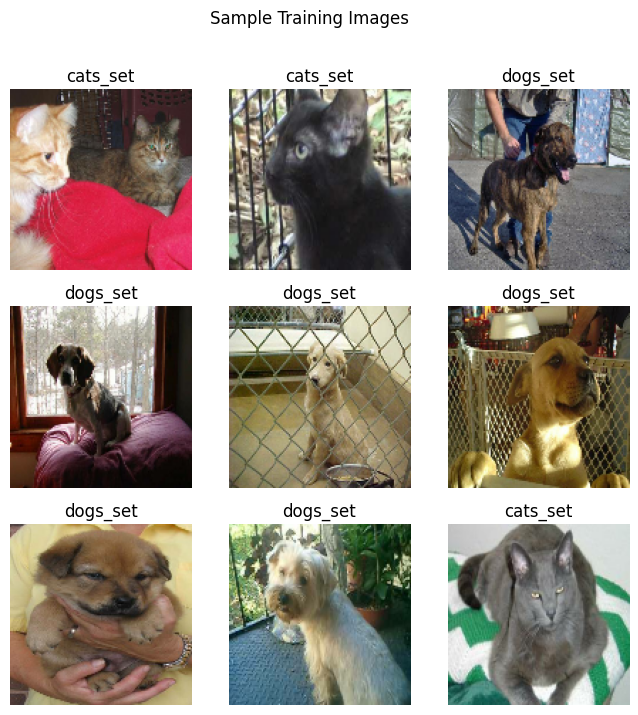

In [6]:
# View one batch of images
plt.figure(figsize=(8, 8))

for images, labels in train_ds_raw.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # display 0–255 RGB correctly
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Sample Training Images")
plt.show()

### Importing padded cat and dog images

In [7]:
# Re-import images with aspect-ratio preservation (padded instead of raw)

train_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # target size for all images
    batch_size=32,                              # number of images per batch
    pad_to_aspect_ratio=True                    # preserve image proportions and pad instead of stretching
)

val_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same target size
    batch_size=32,                              # same batch size
    pad_to_aspect_ratio=True                    # apply same preprocessing to validation data
)

# Split validation into validation + test (50/50 split)
val_batches = tf.data.experimental.cardinality(val_ds_padded).numpy()

test_ds_padded = val_ds_padded.take(val_batches // 2)
val_ds_padded = val_ds_padded.skip(val_batches // 2)

print("Train batches:", tf.data.experimental.cardinality(train_ds_padded).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds_padded).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds_padded).numpy())

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
Train batches: 25
Validation batches: 4
Test batches: 3


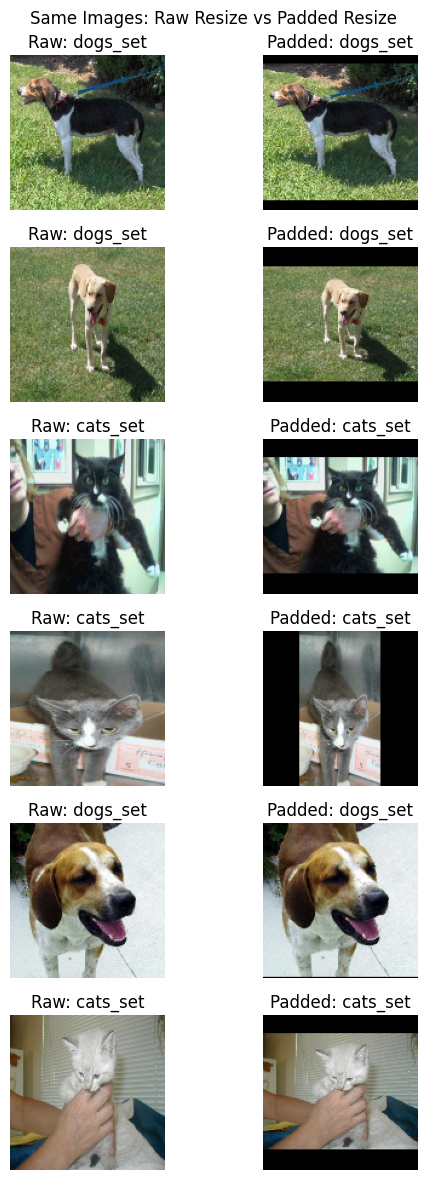

In [8]:
random.seed(42)

cat_paths = list(Path(data_dir).glob("cats_set/*"))
dog_paths = list(Path(data_dir).glob("dogs_set/*"))

image_paths = random.sample(cat_paths, 3) + random.sample(dog_paths, 3)
random.shuffle(image_paths)

plt.figure(figsize=(6, 12))

for i, path in enumerate(image_paths):
    img = tf.io.read_file(str(path))
    img = tf.image.decode_jpeg(img, channels=3)

    raw_img = tf.image.resize(img, (128, 128))
    padded_img = tf.image.resize_with_pad(img, 128, 128)

    label = path.parent.name

    plt.subplot(6, 2, 2*i + 1)
    plt.imshow(raw_img.numpy().astype("uint8"))
    plt.title(f"Raw: {label}")
    plt.axis("off")

    plt.subplot(6, 2, 2*i + 2)
    plt.imshow(padded_img.numpy().astype("uint8"))
    plt.title(f"Padded: {label}")
    plt.axis("off")

plt.suptitle("Same Images: Raw Resize vs Padded Resize")
plt.tight_layout()
plt.show()

### Normalize all data and shuffle train data

In [9]:
# Normalize pixel values from 0–255 to 0–1 for all datasets
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds_padded = train_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # normalize images; keep labels unchanged
)

val_ds_padded = val_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to validation data
)

test_ds_padded = test_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to test data
)

# Shuffle only the training data to improve learning 
# Did above but best practice to do after all preprocessing steps
train_ds_padded = train_ds_padded.shuffle(
    1000,                                        # buffer size (>= dataset size for good mixing)
    seed=42                                      # ensures reproducible shuffling
)

In [10]:
# check normalization worked correctly (should be 0–1 range)
for images, labels in train_ds_padded.take(1):
    print(images.numpy().min(), images.numpy().max())

0.0 1.0


2026-05-21 13:35:09.049387: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Building the MLP model

In [11]:
# set random seed for reproducibility
tf.random.set_seed(42)  

# Define the MLP model
mlp_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),       # input is a 128x128 color image
    layers.Flatten(),                        # convert image to a 1D vector (loses spatial structure)
    layers.Dense(128, activation="relu"),    # hidden layer learns patterns from pixel values
    layers.Dense(64, activation="relu"),     # deeper representation of patterns
    layers.Dense(1, activation="sigmoid")    # output: probability of one class (binary classification)
])

# Compile the model
mlp_catdog.compile(
    optimizer="adam",                        # optimization algorithm
    loss="binary_crossentropy",              # loss for binary classification
    metrics=["accuracy"]                     # track accuracy during training
)

# summary of the MLP model architecture
mlp_catdog.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,299,905 (24.03 MB)

 Trainable params: 6,299,905 (24.03 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# train the MLP model
mlp_history = mlp_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=10
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_catdog.evaluate(test_ds_padded, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.5138 - loss: 3.1094 - val_accuracy: 0.6154 - val_loss: 0.9323
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5713 - loss: 0.8776 - val_accuracy: 0.5288 - val_loss: 1.0047
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.5962 - loss: 0.7246 - val_accuracy: 0.5288 - val_loss: 0.8751
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6062 - loss: 0.7937 - val_accuracy: 0.4712 - val_loss: 1.7772
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5838 - loss: 0.9267 - val_accuracy: 0.5096 - val_loss: 1.2314
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6675 - loss: 0.7302 - val_accuracy: 0.5288 - val_loss: 0.7663
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7525 - loss: 0.5154 - val_accuracy: 0.5577 - val_loss: 0.9903
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7250 - loss: 0.5370 - val_accuracy: 0.5288 - v

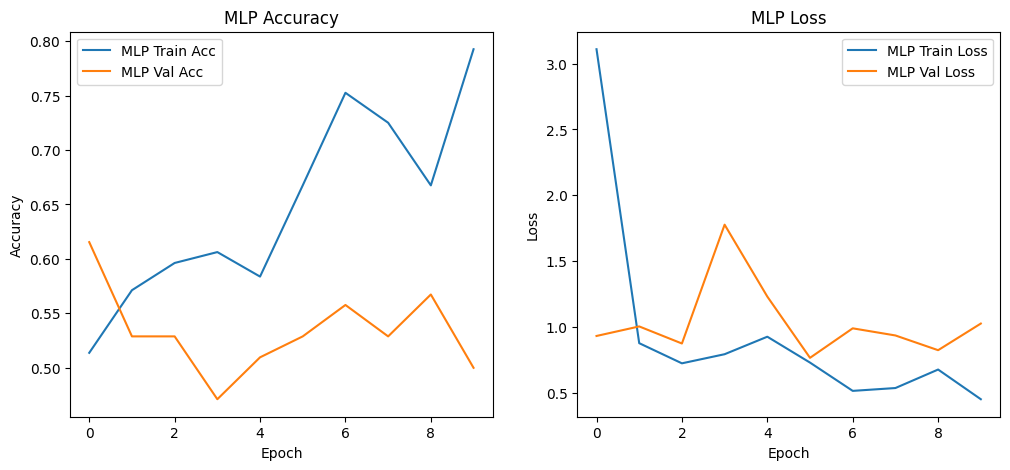

In [13]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mlp_history.history['accuracy'], label='MLP Train Acc')
plt.plot(mlp_history.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mlp_history.history['loss'], label='MLP Train Loss')
plt.plot(mlp_history.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### Building CNN model

In [14]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu", 
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu", 
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20                                      # increase if needed
)

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 301ms/step - accuracy: 0.5562 - loss: 0.8530 - val_accuracy: 0.5385 - val_loss: 0.6995
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 294ms/step - accuracy: 0.6350 - loss: 0.6377 - val_accuracy: 0.5577 - val_loss: 0.7203
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 295ms/step - accuracy: 0.7312 - loss: 0.5446 - val_accuracy: 0.5673 - val_loss: 0.7792
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 272ms/step - accuracy: 0.8000 - loss: 0.4360 - val_accuracy: 0.5096 - val_loss: 0.7665
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 285ms/step - accuracy: 0.8475 - loss: 0.3422 - val_accuracy: 0.5962 - val_loss: 0.8864
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 321ms/step - accuracy: 0.9087 - loss: 0.2381 - val_accuracy: 0.6154 - val_loss: 0.9620
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 294ms/step - accuracy: 0.9538 - loss: 0.1434 - val_accuracy: 0.5673 - val_loss: 0.9087
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 279ms/step - accuracy: 0.9887 - loss: 0.0840 - val_accuracy: 0.

### Visualizing CNN performance

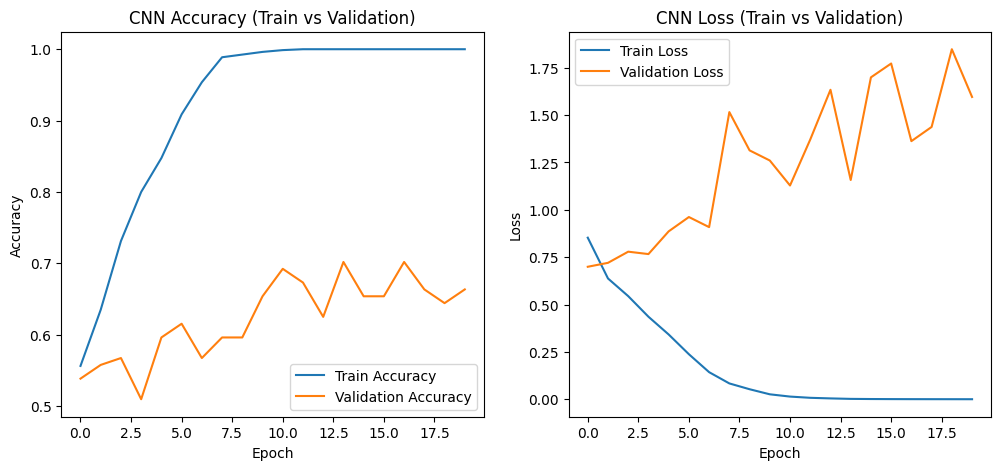

In [15]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### CNN with early stopping

In [16]:
# add early stopping to CNN model
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",                         # watch validation loss
    patience=5,                                 # stop if no improvement for 5 epochs
    restore_best_weights=True                   # revert to best model after stopping
)

# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu", 
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu", 
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20,                                     # increase if needed
    callbacks=[early_stopping]                     # add early stopping callback
)                   

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 294ms/step - accuracy: 0.5562 - loss: 0.8056 - val_accuracy: 0.5865 - val_loss: 0.6808
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 380ms/step - accuracy: 0.6100 - loss: 0.6640 - val_accuracy: 0.4904 - val_loss: 0.7301
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 280ms/step - accuracy: 0.6413 - loss: 0.6322 - val_accuracy: 0.6250 - val_loss: 0.6492
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 277ms/step - accuracy: 0.6775 - loss: 0.5786 - val_accuracy: 0.5385 - val_loss: 0.7174
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 310ms/step - accuracy: 0.7563 - loss: 0.5193 - val_accuracy: 0.5962 - val_loss: 0.6705
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 433ms/step - accuracy: 0.8150 - loss: 0.3978 - val_accuracy: 0.5673 - val_loss: 0.7321
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 320ms/step - accuracy: 0.8725 - loss: 0.3007 - val_accuracy: 0.5577 - val_loss: 0.7855
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 311ms/step - accuracy: 0.9500 - loss: 0.1834 - val_accuracy: 

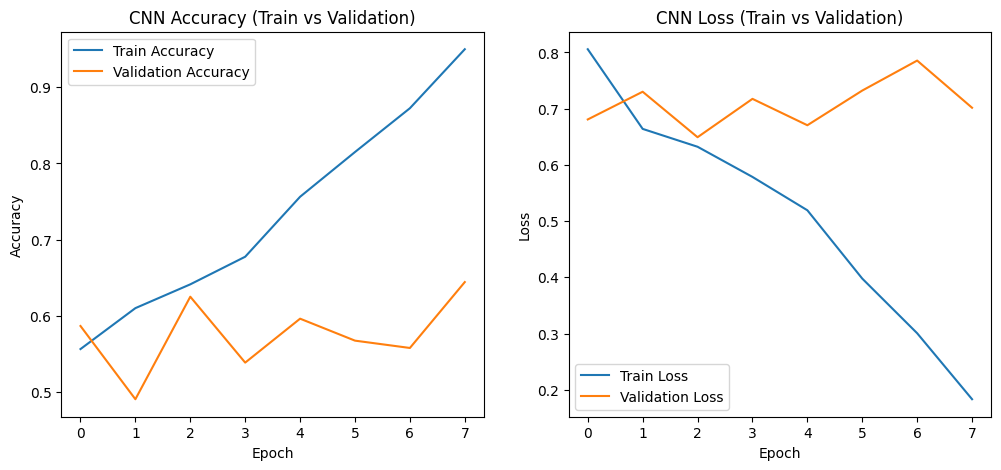

In [17]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### Does CNN performance improve with data augmentation?

In [18]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define data augmentation
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),                # randomly rotate training images
    layers.RandomFlip("horizontal")             # randomly flip images left/right
])

# define CNN model with data augmentation
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),          # input: 128x128 RGB image

    data_augmentation,                          # apply augmentation during training only

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# compile augmented CNN model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# train augmented CNN model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
)

# evaluate augmented CNN on test set
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 327ms/step - accuracy: 0.5213 - loss: 1.0522 - val_accuracy: 0.5192 - val_loss: 0.6935
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 377ms/step - accuracy: 0.5875 - loss: 0.6742 - val_accuracy: 0.5481 - val_loss: 0.6985
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 439ms/step - accuracy: 0.6300 - loss: 0.6500 - val_accuracy: 0.5577 - val_loss: 0.7200
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 431ms/step - accuracy: 0.6463 - loss: 0.6271 - val_accuracy: 0.5577 - val_loss: 0.7215
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 486ms/step - accuracy: 0.6787 - loss: 0.5936 - val_accuracy: 0.5481 - val_loss: 0.7033
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.6775 - loss: 0.6017 - val_accuracy: 0.5192 - val_loss: 0.6895
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 305ms/step - accuracy: 0.7025 - loss: 0.5841 - val_accuracy: 0.5673 - val_loss: 0.7502
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 381ms/step - accuracy: 0.6938 - loss: 0.5687 - val_accura

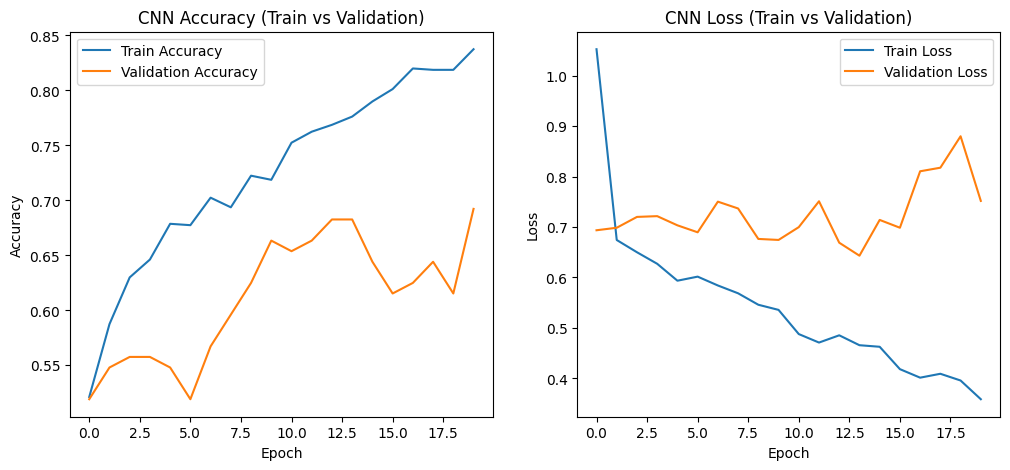

In [19]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code for you to experiment with

Use the code cell below as a starting point. Train at least 3 different CNN models by changing augmentation, regularization, and/or model capacity. Examples include adding rotation, zoom, L2 regularization, dropout, or another convolutional layer. Compare training, validation, and test performance, and explain which model generalizes best.

In [20]:
# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    # layers.RandomRotation(0.05),
    # layers.RandomZoom(0.05),
    # layers.RandomTranslation(0.05, 0.05),
    # layers.RandomContrast(0.1)
])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Optional added capacity
    # layers.Conv2D(
    #     128, (3, 3),
    #     padding="same",
    #     # kernel_regularizer=regularizers.l2(0.0005)
    # ),
    # # layers.BatchNormalization(),
    # layers.Activation("relu"),
    # layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional dropout
    # layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

# Compile model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 277ms/step - accuracy: 0.5337 - loss: 0.7813 - val_accuracy: 0.4904 - val_loss: 0.6923
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 267ms/step - accuracy: 0.5938 - loss: 0.6672 - val_accuracy: 0.5481 - val_loss: 0.7321
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 302ms/step - accuracy: 0.6350 - loss: 0.6454 - val_accuracy: 0.5385 - val_loss: 0.7026
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 276ms/step - accuracy: 0.6562 - loss: 0.5912 - val_accuracy: 0.5673 - val_loss: 0.7095
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 415ms/step - accuracy: 0.7150 - loss: 0.5502 - val_accuracy: 0.5769 - val_loss: 0.6955
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 286ms/step - accuracy: 0.7588 - loss: 0.4897 - val_accuracy: 0.6442 - val_loss: 0.6332
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 392ms/step - accuracy: 0.8250 - loss: 0.4060 - val_accuracy: 0.6442 - val_loss: 0.6681
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 468ms/step - accuracy: 0.8550 - loss: 0.3219 - val_accuracy:

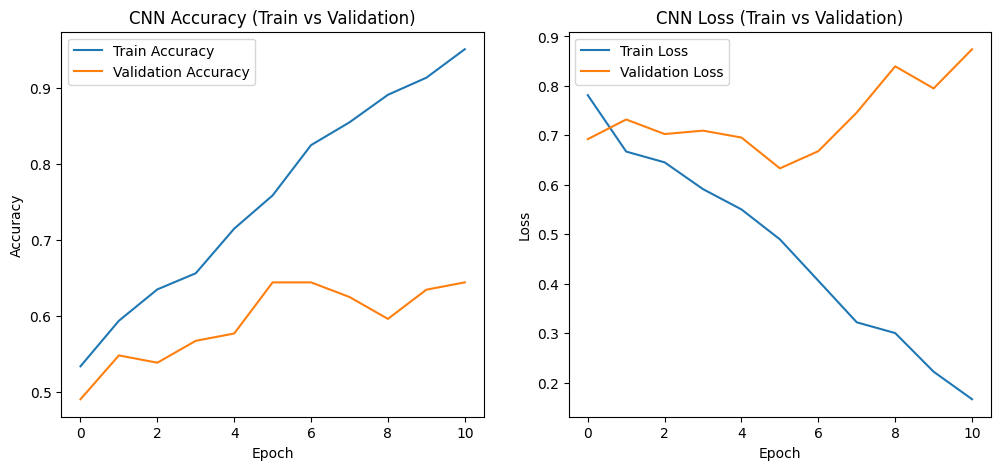

In [21]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code cells for your 3+ models. Make sure to annotate for each, explaining what you tried

In [22]:
# --- Experiment: 3 CNN configs (change ONE main idea per model) ---
# Fair comparison: same data splits, seed, early stopping, max 20 epochs

def build_and_train_cnn(name, augment_layers, conv_blocks, dense_units=64, dropout_rate=None, l2_rate=None):
    """conv_blocks: list of filter counts, e.g. [32, 64] or [32, 64, 128]"""
    keras.backend.clear_session()
    tf.random.set_seed(42)

    reg = regularizers.l2(l2_rate) if l2_rate else None
    aug = models.Sequential(augment_layers) if augment_layers else None

    layers_list = [layers.Input(shape=(128, 128, 3))]
    if aug is not None:
        layers_list.append(aug)

    for f in conv_blocks:
        layers_list += [
            layers.Conv2D(f, (3, 3), padding="same", kernel_regularizer=reg),
            layers.Activation("relu"),
            layers.MaxPooling2D((2, 2)),
        ]

    layers_list += [layers.Flatten()]
    layers_list += [
        layers.Dense(dense_units, activation="relu", kernel_regularizer=reg),
    ]
    if dropout_rate:
        layers_list.append(layers.Dropout(dropout_rate))
    layers_list.append(layers.Dense(1, activation="sigmoid"))

    model = models.Sequential(layers_list)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
    history = model.fit(
        train_ds_padded,
        validation_data=val_ds_padded,
        epochs=20,
        callbacks=[early_stop],
        verbose=0,
    )
    test_loss, test_acc = model.evaluate(test_ds_padded, verbose=0)

    last = len(history.history["loss"]) - 1
    return {
        "model": name,
        "epochs_run": last + 1,
        "train_acc": history.history["accuracy"][last],
        "val_acc": history.history["val_accuracy"][last],
        "test_acc": test_acc,
        "train_loss": history.history["loss"][last],
        "val_loss": history.history["val_loss"][last],
        "test_loss": test_loss,
        "history": history,
    }


# Model 1 — Baseline aug: horizontal flip only (matches starting template)
flip_only = [
    layers.RandomFlip("horizontal"),
]

# Model 2 — Stronger augmentation: flip + rotation + zoom (no architecture change)
strong_aug = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
]

# Model 3 — Regularization: flip only + dropout + L2 (same capacity as Model 1)
# (If train accuracy >> val accuracy on Model 1, this is the lever to try.)

experiment_results = []
experiment_results.append(
    build_and_train_cnn(
        "1_flip_only",
        flip_only,
        conv_blocks=[32, 64],
    )
)
experiment_results.append(
    build_and_train_cnn(
        "2_strong_aug",
        strong_aug,
        conv_blocks=[32, 64],
    )
)
experiment_results.append(
    build_and_train_cnn(
        "3_dropout_l2",
        flip_only,
        conv_blocks=[32, 64],
        dropout_rate=0.3,
        l2_rate=1e-4,
    )
)

# Optional 4th: more capacity — uncomment if Models 1–3 underfit (low train AND val acc)
# experiment_results.append(
#     build_and_train_cnn("4_deeper", flip_only, conv_blocks=[32, 64, 128])
# )

rows = []
for r in experiment_results:
    rows.append({
        "model": r["model"],
        "epochs": r["epochs_run"],
        "train_acc": round(r["train_acc"], 4),
        "val_acc": round(r["val_acc"], 4),
        "test_acc": round(r["test_acc"], 4),
        "train_val_gap": round(r["train_acc"] - r["val_acc"], 4),
        "val_loss": round(r["val_loss"], 4),
        "test_loss": round(r["test_loss"], 4),
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))
print("\nGeneralization hint: prefer high test_acc with small train_val_gap and val_loss close to test_loss.")

       model  epochs  train_acc  val_acc  test_acc  train_val_gap  val_loss  test_loss
 1_flip_only      11     0.8788   0.6154    0.5938         0.2634    0.7807     0.6781
2_strong_aug      17     0.7300   0.6154    0.6042         0.1146    0.7537     0.6811
3_dropout_l2       9     0.8150   0.6442    0.6042         0.1708    0.7225     0.6821

Generalization hint: prefer high test_acc with small train_val_gap and val_loss close to test_loss.


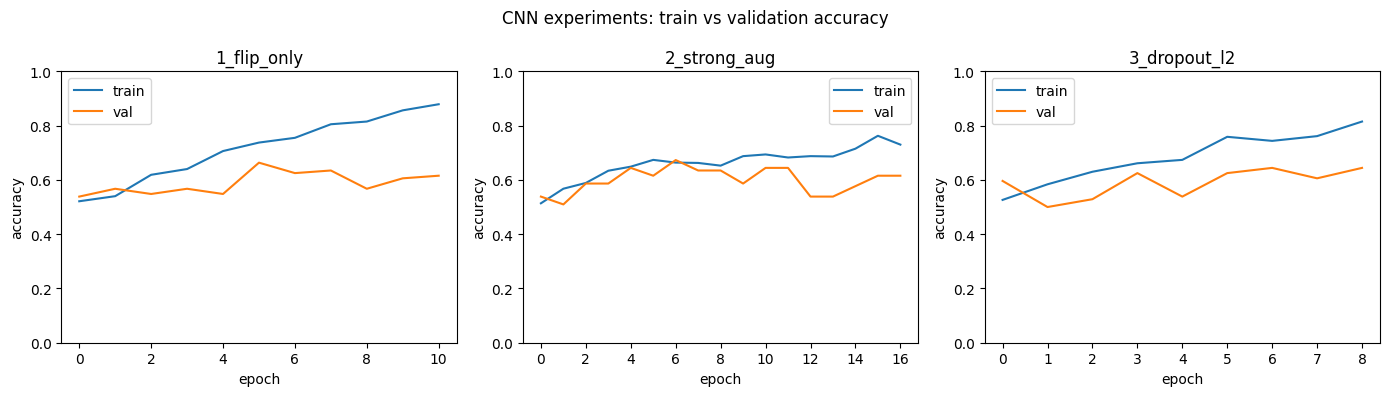

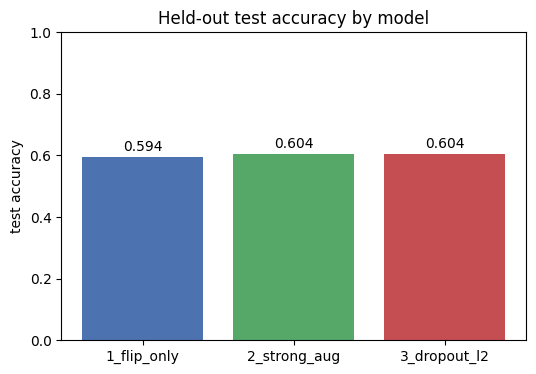

In [23]:
# Plot train vs validation accuracy for all three experiments
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, r in zip(axes, experiment_results):
    h = r["history"].history
    ax.plot(h["accuracy"], label="train")
    ax.plot(h["val_accuracy"], label="val")
    ax.set_title(r["model"])
    ax.set_xlabel("epoch")
    ax.set_ylabel("accuracy")
    ax.legend()
    ax.set_ylim(0, 1)
plt.suptitle("CNN experiments: train vs validation accuracy")
plt.tight_layout()
plt.show()

# Bar chart: test accuracy comparison
plt.figure(figsize=(6, 4))
plt.bar(results_df["model"], results_df["test_acc"], color=["#4c72b0", "#55a868", "#c44e52"])
plt.ylabel("test accuracy")
plt.title("Held-out test accuracy by model")
plt.ylim(0, 1)
for i, v in enumerate(results_df["test_acc"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.show()

### What seemed to help model performance most in your experiments?

#### Results summary (from notebook outputs)

| Model | Test acc | Train acc (last epoch) | Val acc (last epoch) | Notes |
|-------|----------|------------------------|----------------------|-------|
| MLP (flattened) | 0.521 | 0.793 | 0.500 | Near chance; no spatial structure |
| CNN (20 epochs) | **0.656** | 1.000 | 0.702 | Heavy overfitting (train ≫ val) |
| CNN + early stopping | 0.563 | 0.950 | 0.644 | Stopped at epoch 8; test lower than full CNN |
| CNN + aug (flip + rotation) | **0.677** | 0.838 | 0.692 | Best test acc in main section |
| **1_flip_only** (experiment) | 0.594 | 0.879 | 0.615 | Large train–val gap (0.26) |
| **2_strong_aug** (experiment) | **0.604** | 0.730 | 0.615 | Smallest gap (0.11); tied best test |
| **3_dropout_l2** (experiment) | **0.604** | 0.815 | **0.644** | Best val acc; dropout + L2 |

#### Which model generalizes best?

- **Best test accuracy (3 experiment models):** **2_strong_aug** and **3_dropout_l2** (test acc = **0.604** each; flip-only was 0.594)
- **Smallest train–val gap:** **2_strong_aug** (gap = **0.115**)
- **What helped most:** **Stronger augmentation** (flip + rotation + zoom) and **regularization** (dropout + L2) both beat flip-only on test accuracy and reduced overfitting. **CNNs overall** helped most vs the MLP (~52% test). **Early stopping** limited training time but did not beat the best CNN runs on test. The **padded resize** + normalization pipeline was necessary before any model could learn.

**Short conclusion:** Among the three experiment CNNs, **2_strong_aug** generalizes best: it ties for highest test accuracy (**0.604**) with the smallest train–validation gap (**0.115**), so validation tracks training more closely than flip-only (gap **0.26**). Flip-only overfit (train **0.88** vs val **0.62**). Dropout + L2 matched test accuracy and improved validation (**0.644**) but still had a larger gap than strong augmentation. Overall, **using convolutions and data augmentation** mattered most on this small dataset (800 train images); the best single run in the notebook was the earlier **CNN with flip + rotation** (test **0.677**).